<a href="https://colab.research.google.com/github/brandon5254/Data_Science/blob/main/ClusterBrandonTobar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Parcial 2 corte Gestion Analisis De Datos
Estudiante: Brandon Eduardo Tobar Sanchez

Docente: Giovanny Hidalgo

In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import plotly.express as px
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics  import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Preprocesamiento y escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Modelos de Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Evaluación del Clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Reducción de dimensionalidad (opcional para visualización)
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Parte 1: Análisis y Preprocesamiento

In [ ]:
import pandas as pd

# URL del archivo en bruto desde GitHub
url = 'https://raw.githubusercontent.com/brandon5254/Wholesale-customers/refs/heads/main/Wholesale%20customers%20data.csv'

# Cargar el archivo CSV en un DataFrame
df = pd.read_csv(url)

# Mostrar las primeras filas
df


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


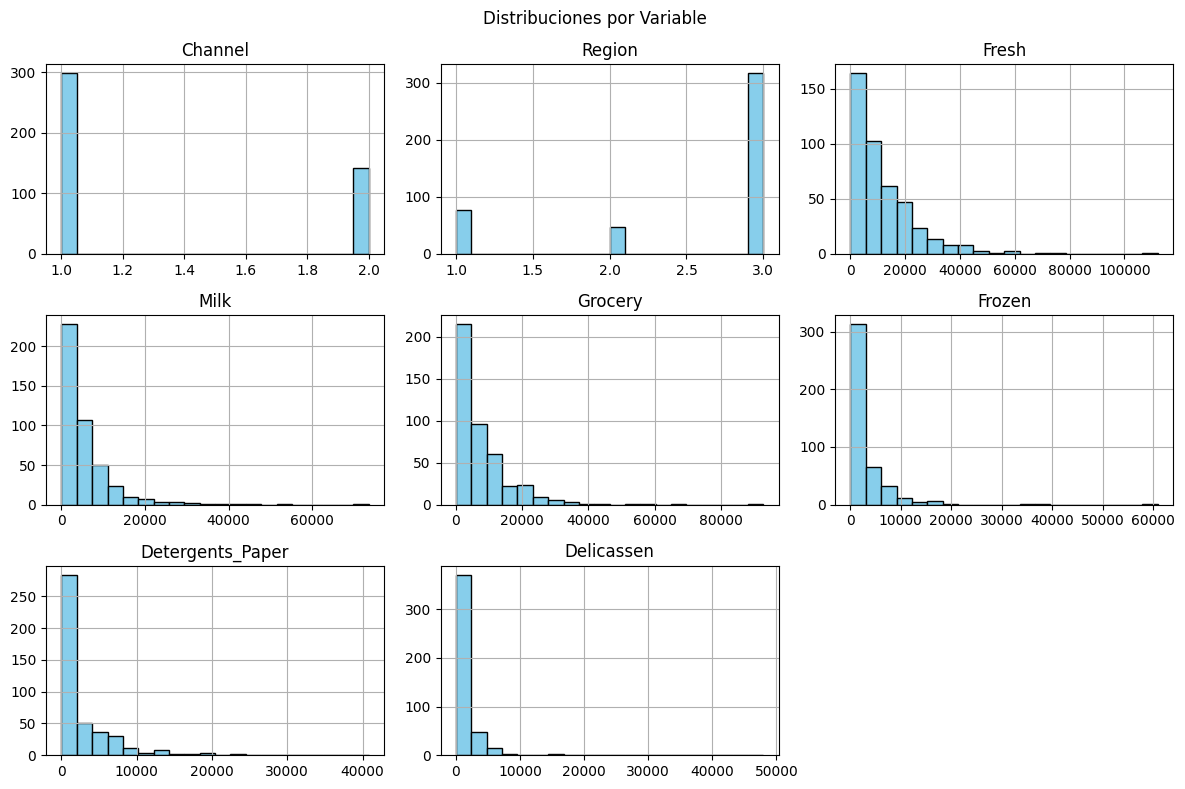

In [ ]:
#Histograma para ver la distribución de todas las variables numéricas
df.hist(figsize=(12, 8), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Distribuciones por Variable")
plt.tight_layout()
plt.show()


In [ ]:
# Ver estructura general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
# Ver estadísticas básicas
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [ ]:
# Ver si hay valores nulos
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


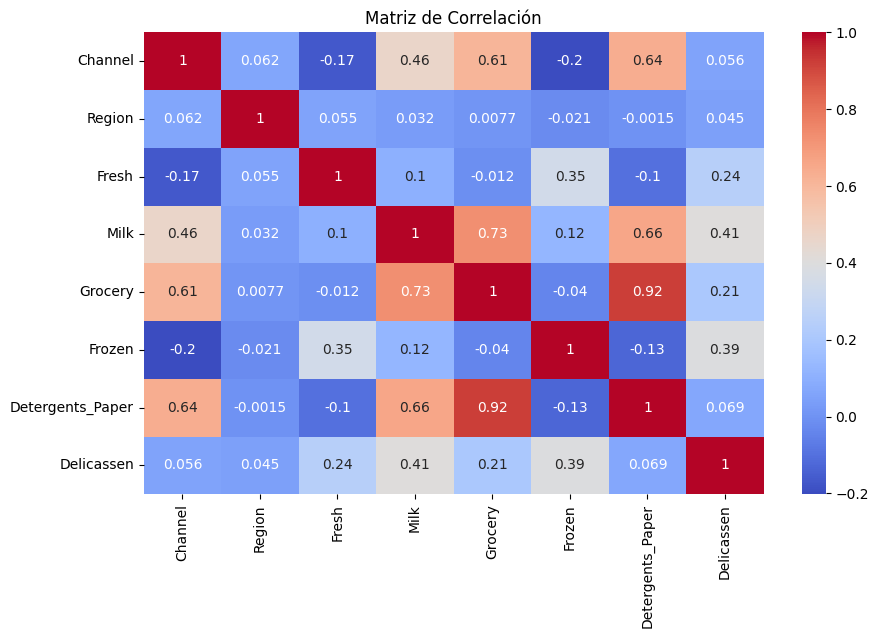

In [ ]:
# Matriz de Correlacion entre variables numéricas

# Crea una figura con tamaño adecuado para visualizar la matriz
plt.figure(figsize=(10, 6))

# Genera un mapa de calor (heatmap) con la matriz de correlación
sns.heatmap(
    df.corr(),        # Calcula las correlaciones entre todas las variables numéricas
    annot=True,       # Muestra los valores numéricos dentro de cada celda
    cmap='coolwarm'   # Esquema de color que va del azul (correlación negativa) al rojo (positiva)
)

# Título del gráfico
plt.title("Matriz de Correlación")

# Muestra el heatmap
plt.show()


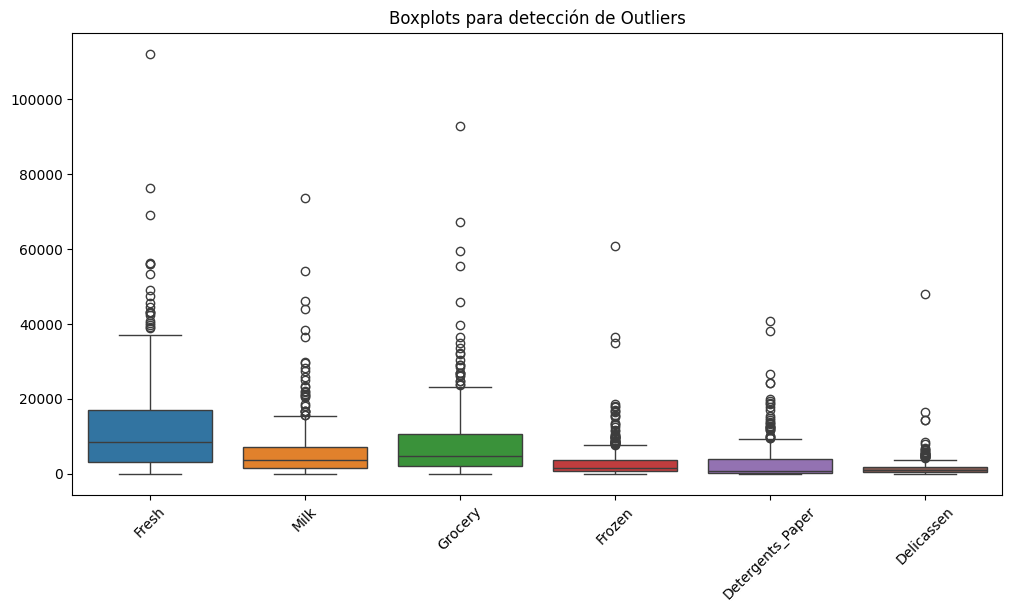

In [ ]:
# Boxplots para detectar outliers

# Eliminamos las columnas categóricas 'Channel' y 'Region' para enfocarnos solo en las numéricas
df_features = df.drop(columns=['Channel', 'Region'])

# Definimos el tamaño de la figura para que los gráficos se vean bien
plt.figure(figsize=(12, 6))

# Creamos el boxplot para todas las variables numéricas al mismo tiempo
sns.boxplot(data=df_features)

# Agregamos un título al gráfico
plt.title("Boxplots para detección de Outliers")

# Rotamos las etiquetas del eje X para mejor visualización
plt.xticks(rotation=45)

# Mostramos el gráfico
plt.show()


In [ ]:
# Análisis de Asimetría y Curtosis

# Imprime la asimetría (skewness) de cada variable numérica
# Skew > 0 indica sesgo a la derecha, Skew < 0 indica sesgo a la izquierda
print("Asimetría (Skew):")
print(df_features.skew())

# Imprime la curtosis (kurtosis) de cada variable
# Curtosis alta indica colas pesadas (más outliers), baja indica colas ligeras
print("\nCurtosis:")
print(df_features.kurt())


Asimetría (Skew):
Fresh                2.561323
Milk                 4.053755
Grocery              3.587429
Frozen               5.907986
Detergents_Paper     3.631851
Delicassen          11.151586
dtype: float64

Curtosis:
Fresh                11.536408
Milk                 24.669398
Grocery              20.914670
Frozen               54.689281
Detergents_Paper     19.009464
Delicassen          170.694939
dtype: float64


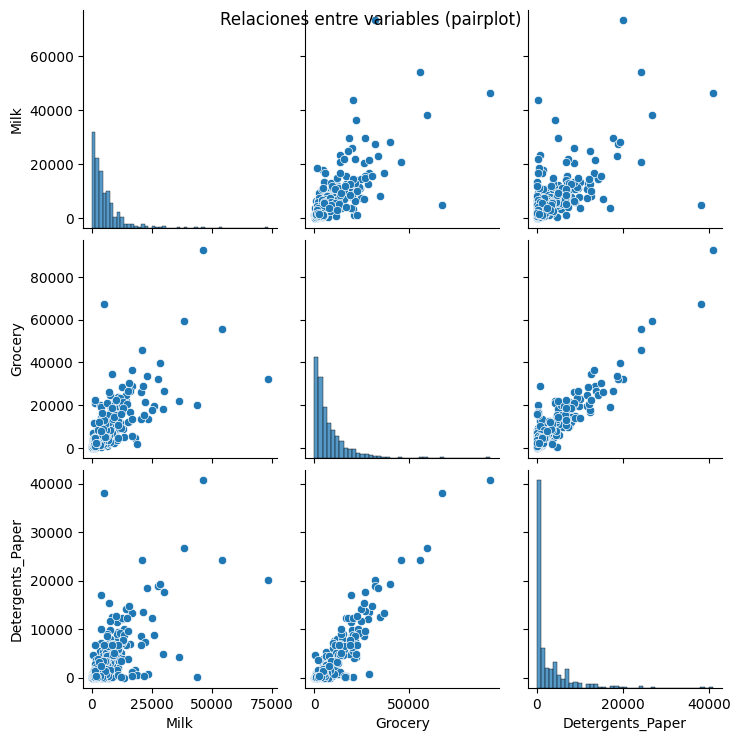

In [ ]:
# Crea un pairplot para visualizar las relaciones bivariadas entre tres variables seleccionadas
# Este tipo de gráfico muestra diagramas de dispersión (scatterplots) entre pares de variables
# y distribuciones en la diagonal para detectar patrones, correlaciones o agrupaciones naturales
sns.pairplot(df_features[['Milk', 'Grocery', 'Detergents_Paper']])

# Título general del gráfico
plt.suptitle("Relaciones entre variables (pairplot)")

# Muestra el gráfico
plt.show()


In [ ]:


# Cargar dataset

# Definir variables categóricas y numéricas
cat_vars = ['Channel', 'Region']
num_vars = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# Convertir a categorías
df[cat_vars] = df[cat_vars].astype('category')

# Codificar categóricas
df_encoded = df.copy()
df_encoded[cat_vars] = df_encoded[cat_vars].apply(lambda x: x.cat.codes)

# Preparar SMOTENC para balancear Channel + Region
cat_indices = [df_encoded.columns.get_loc(c) for c in cat_vars]
X = df_encoded.copy()
y = df_encoded['Region'] * 10 + df_encoded['Channel']  # combina ambas para forzar SMOTE multiclase

smote = SMOTENC(categorical_features=cat_indices, random_state=42)
X_resampled, _ = smote.fit_resample(X, y)

# Restaurar Channel y Region
X_resampled['Channel'] = X_resampled['Channel'].round().astype(int)
X_resampled['Region'] = X_resampled['Region'].round().astype(int)

# Aplicar PowerTransformer para normalizar forma + escala
pt = PowerTransformer(method='yeo-johnson')
X_resampled[num_vars] = pt.fit_transform(X_resampled[num_vars])

# Guardar resultado final
df_final = X_resampled.copy()


<ipython-input-12-cb1d7907b412>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Channel', data=df_final, ax=axes[0], palette='pastel')
<ipython-input-12-cb1d7907b412>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region', data=df_final, ax=axes[1], palette='Set2')


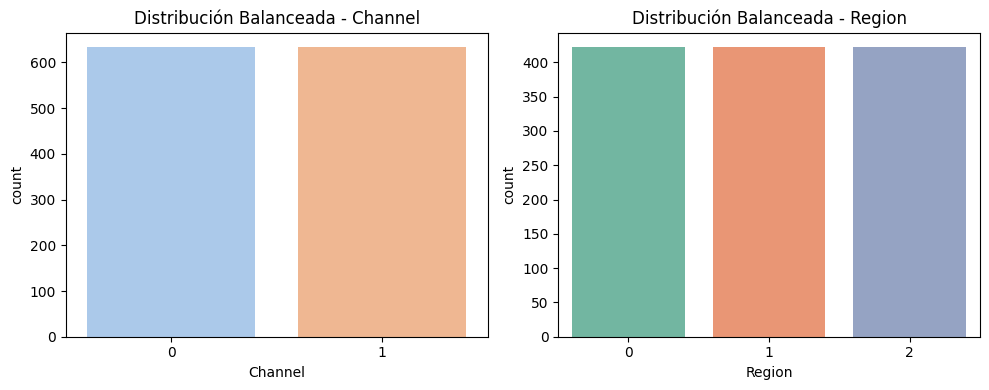

In [ ]:
# Visualización de la distribución balanceada de variables categóricas: 'Channel' y 'Region'

# Crea una figura con dos subgráficos en una fila (1, 2) y define el tamaño total
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras para la variable 'Channel'
sns.countplot(x='Channel', data=df_final, ax=axes[0], palette='pastel')
axes[0].set_title("Distribución Balanceada - Channel")  # Título del primer gráfico

# Gráfico de barras para la variable 'Region'
sns.countplot(x='Region', data=df_final, ax=axes[1], palette='Set2')
axes[1].set_title("Distribución Balanceada - Region")  # Título del segundo gráfico

# Ajusta el espaciado entre los subgráficos para evitar solapamientos
plt.tight_layout()

# Muestra ambos gráficos
plt.show()


<ipython-input-13-e8f0e28ec573>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Channel', data=df_final, ax=axes[0, 0], palette='pastel')
<ipython-input-13-e8f0e28ec573>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region', data=df_final, ax=axes[0, 1], palette='Set2')


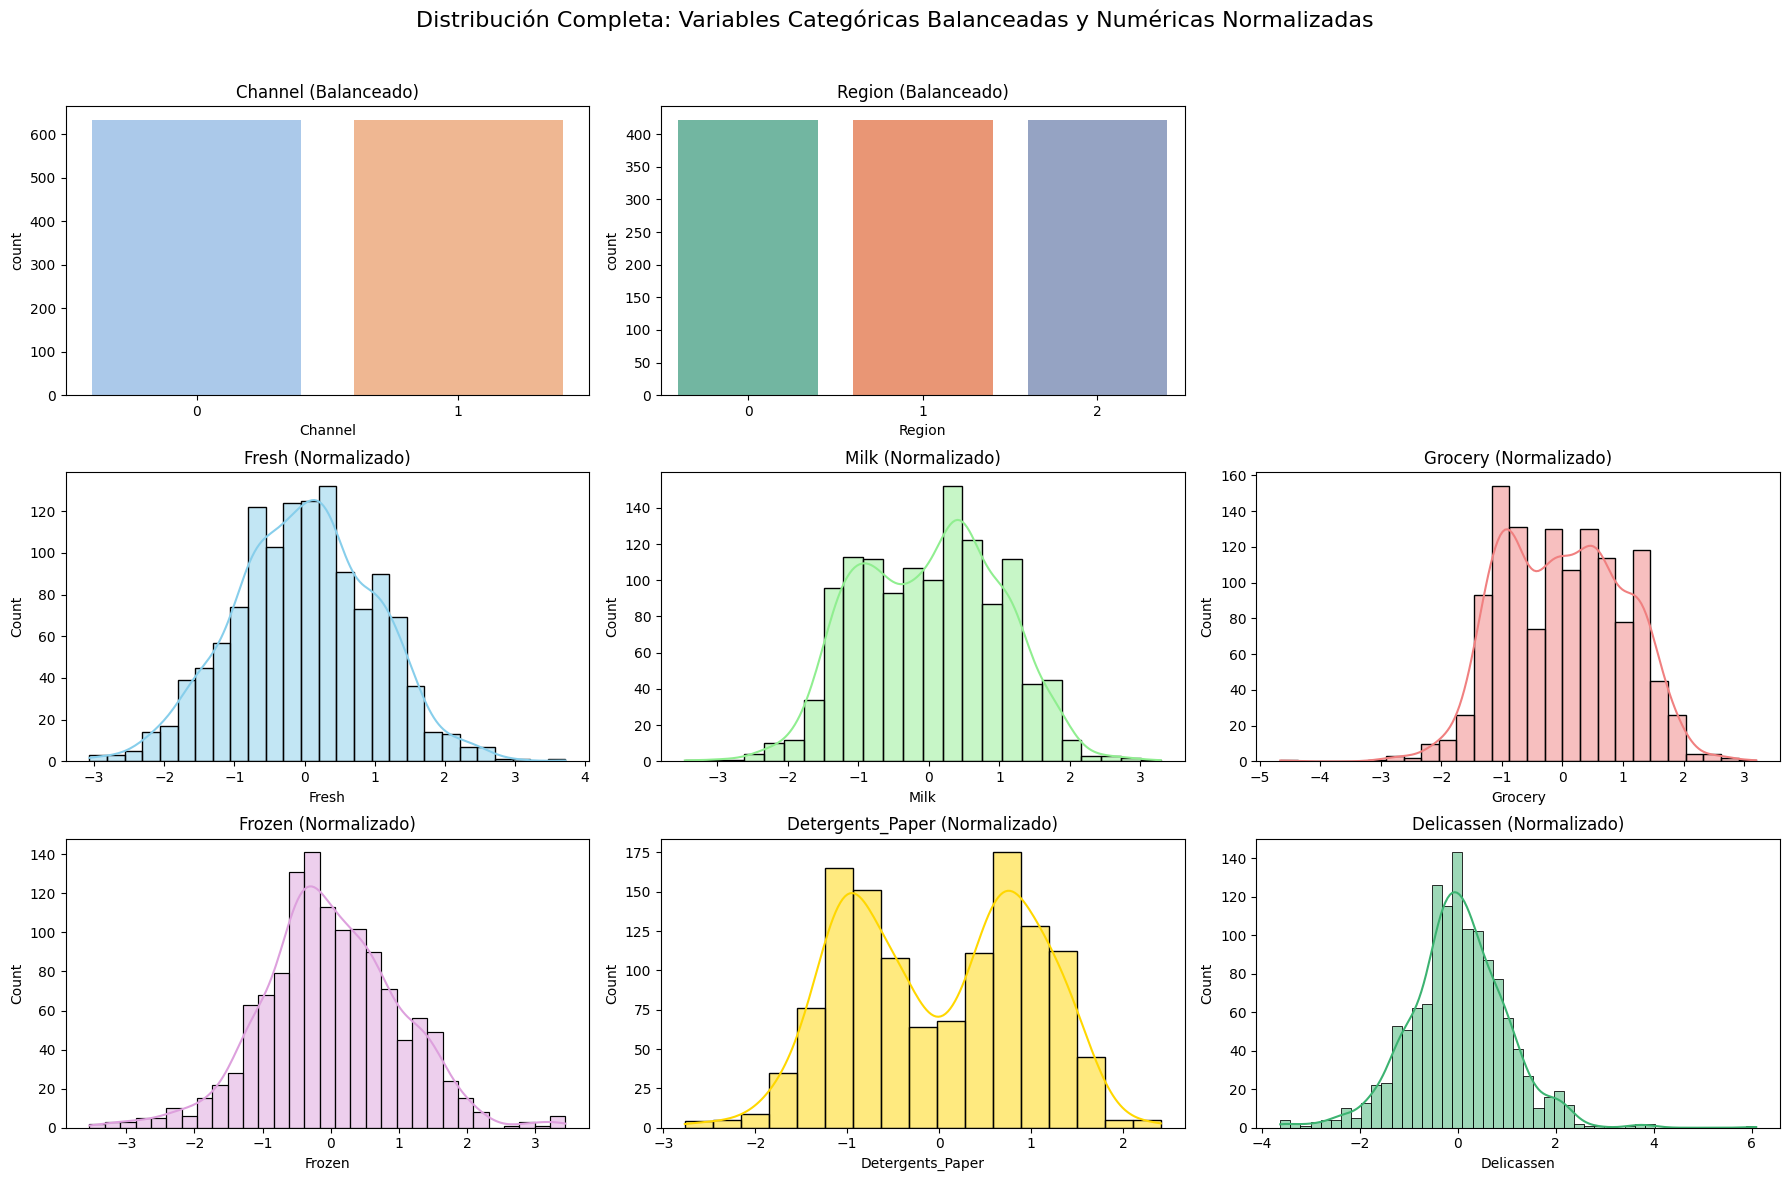

In [ ]:

# Aseguramos que categóricas estén como 'category'
df_final['Channel'] = df_final['Channel'].astype('category')
df_final['Region'] = df_final['Region'].astype('category')

# Crear figura grande
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle("Distribución Completa: Variables Categóricas Balanceadas y Numéricas Normalizadas", fontsize=16)

# Channel y Region (balanceadas)
sns.countplot(x='Channel', data=df_final, ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title("Channel (Balanceado)")

sns.countplot(x='Region', data=df_final, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title("Region (Balanceado)")

axes[0, 2].axis('off')  # Espacio vacío

# Variables numéricas normalizadas (forma campana)
sns.histplot(df_final['Fresh'], kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title("Fresh (Normalizado)")

sns.histplot(df_final['Milk'], kde=True, ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title("Milk (Normalizado)")

sns.histplot(df_final['Grocery'], kde=True, ax=axes[1, 2], color='lightcoral')
axes[1, 2].set_title("Grocery (Normalizado)")

sns.histplot(df_final['Frozen'], kde=True, ax=axes[2, 0], color='plum')
axes[2, 0].set_title("Frozen (Normalizado)")

sns.histplot(df_final['Detergents_Paper'], kde=True, ax=axes[2, 1], color='gold')
axes[2, 1].set_title("Detergents_Paper (Normalizado)")

sns.histplot(df_final['Delicassen'], kde=True, ax=axes[2, 2], color='mediumseagreen')
axes[2, 2].set_title("Delicassen (Normalizado)")

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()


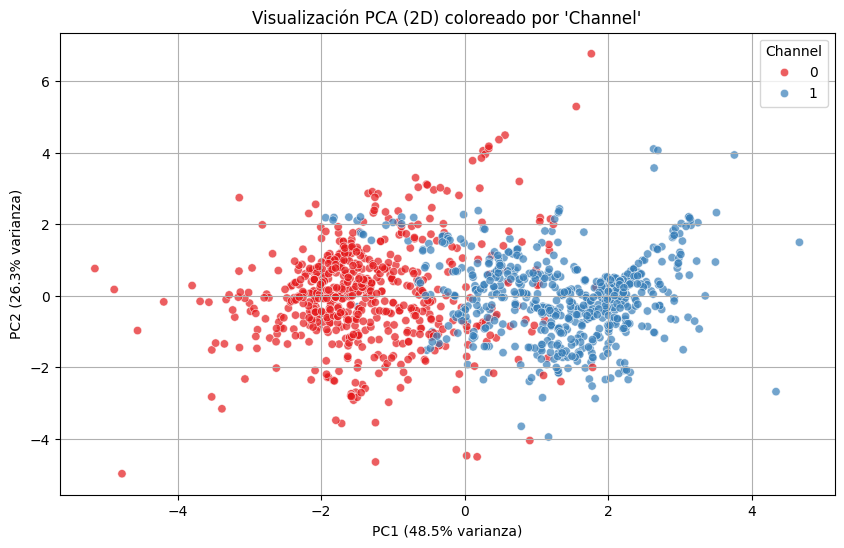

Varianza explicada por componentes principales:
 - Componente 1: 48.46%
 - Componente 2: 26.28%


In [ ]:

# Aplicamos PCA a las variables numéricas normalizadas
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_final[num_vars])

# Guardamos resultados como nuevo DataFrame
df_pca = df_final.copy()
df_pca['PC1'] = pca_result[:, 0]
df_pca['PC2'] = pca_result[:, 1]

# Visualización 2D por categoría (ej: Channel)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Channel', palette='Set1', alpha=0.7)
plt.title("Visualización PCA (2D) coloreado por 'Channel'")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.grid(True)
plt.legend(title='Channel')
plt.show()

# Mostrar porcentaje de varianza explicada
print("Varianza explicada por componentes principales:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f" - Componente {i+1}: {var*100:.2f}%")


# Parte 2: Clustering con K-Means

In [ ]:
# Inicializamos listas vacías para almacenar los resultados de inercia y siluetas
inertias = []
silhouettes = []

# Seleccionamos solo las variables numéricas normalizadas para aplicar K-Means
X = df_final[num_vars]  # 'num_vars' debería contener los nombres de las variables numéricas

# Iteramos por diferentes valores de k (número de clusters), de 2 a 10
for k in range(2, 10):
    # Aplicamos K-Means con el valor de k actual
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Realizamos el ajuste del modelo y predecimos las etiquetas de los clusters
    labels = kmeans.fit_predict(X)

    # Guardamos el valor de la inercia para el número de clusters k (suma de distancias cuadradas a los centroides)
    inertias.append(kmeans.inertia_)

    # Calculamos el índice de silueta para medir la calidad del clustering
    # El índice de silueta refleja qué tan bien se han asignado las muestras a sus clusters
    sil_score = silhouette_score(X, labels)

    # Guardamos el índice de silueta en la lista 'silhouettes'
    silhouettes.append(sil_score)


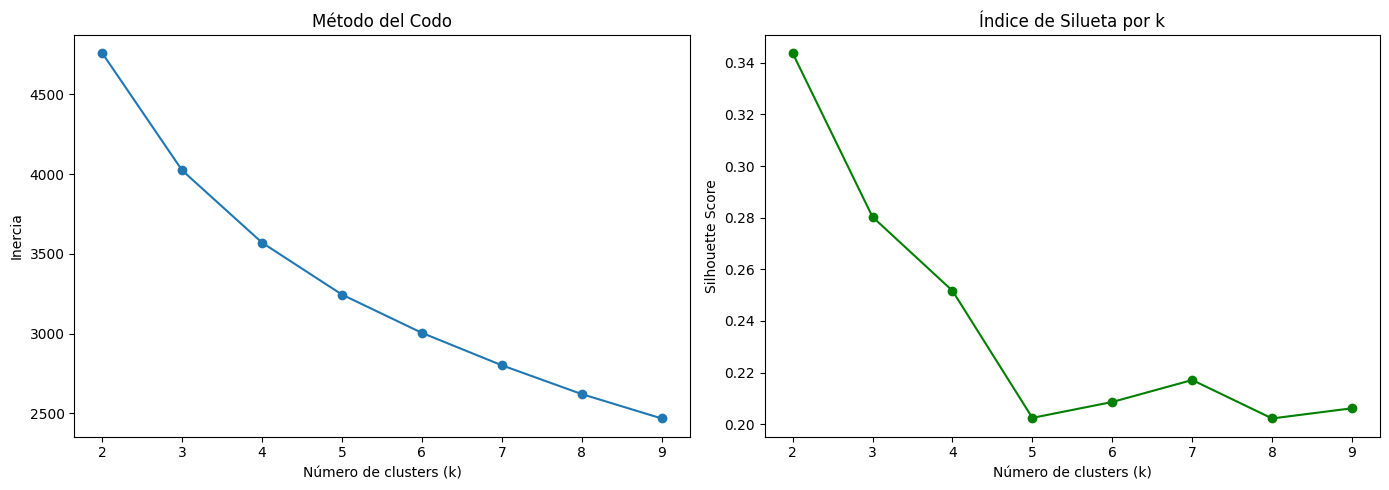

In [ ]:
# Crear una figura con dos subgráficos (uno para el método del codo y otro para el índice de silueta)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Método del Codo: muestra cómo la inercia cambia a medida que se aumenta el número de clusters
ax[0].plot(range(2, 10), inertias, marker='o')  # 'range(2, 11)' indica k de 2 a 10, 'marker' resalta los puntos
ax[0].set_title("Método del Codo")  # Título del gráfico
ax[0].set_xlabel("Número de clusters (k)")  # Etiqueta del eje X
ax[0].set_ylabel("Inercia")  # Etiqueta del eje Y

# Gráfico del Índice de Silueta: muestra cómo cambia el índice de silueta para cada k
ax[1].plot(range(2, 10), silhouettes, marker='o', color='green')  # Se visualiza el índice de silueta con color verde
ax[1].set_title("Índice de Silueta por k")  # Título del gráfico
ax[1].set_xlabel("Número de clusters (k)")  # Etiqueta del eje X
ax[1].set_ylabel("Silhouette Score")  # Etiqueta del eje Y

# Ajusta automáticamente el espaciado entre los subgráficos para evitar solapamientos
plt.tight_layout()

# Muestra los gráficos generados
plt.show()


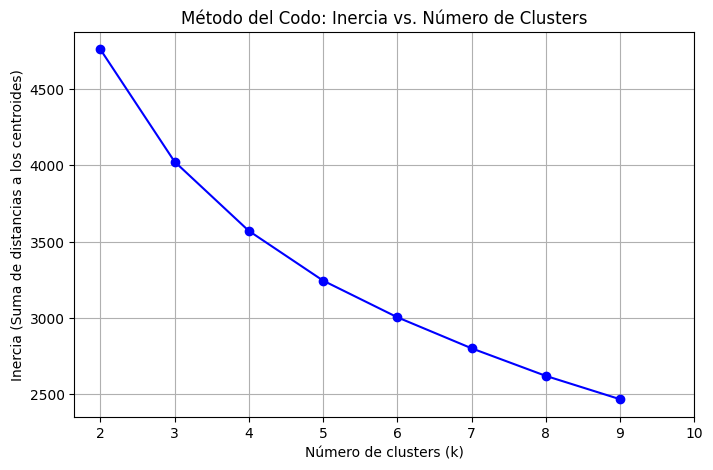

In [ ]:
# Gráfica del método del codo
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), inertias, marker='o', linestyle='-', color='b')
plt.title("Método del Codo: Inercia vs. Número de Clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (Suma de distancias a los centroides)")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()


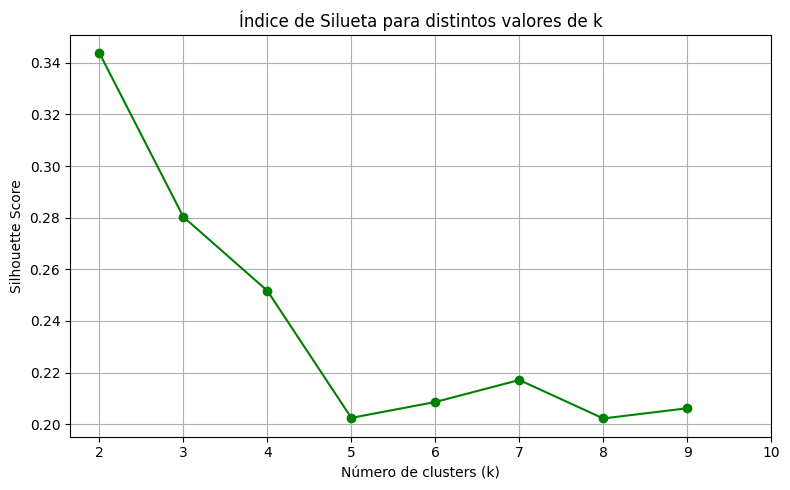

In [ ]:
# gráfico de líneas que muestra cómo varía el índice de silueta para diferentes valores de k
plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), silhouettes, marker='o', color='green')
plt.title("Índice de Silueta para distintos valores de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Definimos el número óptimo de clusters (k) basado en el análisis previo,  k=3
k_optimo = 3

# Aplicamos el modelo de K-Means con el valor de k óptimo
# n_init=10 significa que el algoritmo se ejecutará 10 veces con diferentes inicializaciones para garantizar estabilidad
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Usamos el modelo para predecir los clusters para cada observación
# 'fit_predict' ajusta el modelo a los datos X y devuelve las etiquetas de los clusters
# Añadimos las etiquetas predichas a nuestro DataFrame df_pca en una nueva columna 'Cluster'
df_pca['Cluster'] = kmeans_final.fit_predict(X)


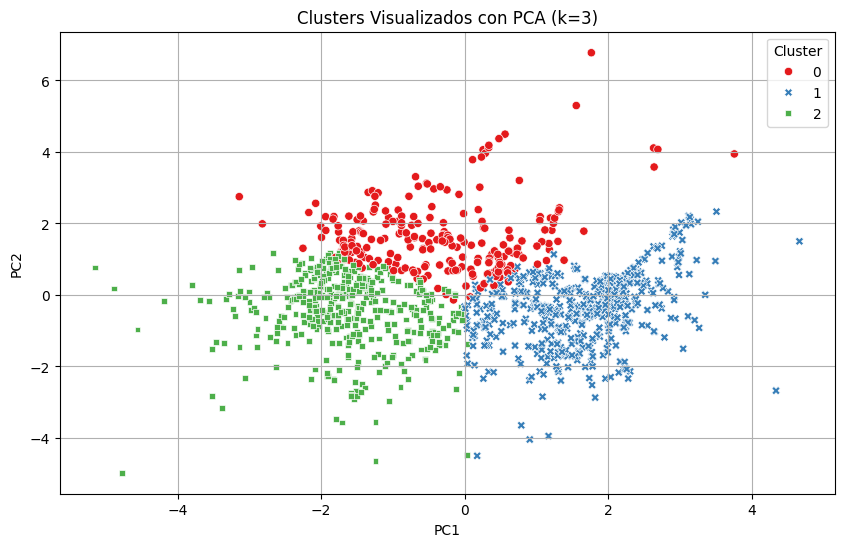

In [ ]:
# Crear una figura con tamaño específico para la visualización
plt.figure(figsize=(10, 6))

# Crear un gráfico de dispersión (scatter plot) para visualizar los clusters en 2D
# 'PC1' y 'PC2' son las dos primeras componentes principales obtenidas con PCA
# 'hue' asigna un color diferente a cada cluster, 'style' cambia el estilo de los puntos según el cluster
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set1', style='Cluster')

# Título del gráfico, donde se incluye el número de clusters (k) determinado previamente
plt.title(f"Clusters Visualizados con PCA (k={k_optimo})")

# Etiquetas de los ejes X e Y para las componentes principales
plt.xlabel("PC1")
plt.ylabel("PC2")

# Añadir la leyenda para identificar los clusters
plt.legend(title="Cluster")

# Activar la cuadrícula para facilitar la visualización
plt.grid(True)

# Mostrar el gráfico generado
plt.show()


# Parte 3: Clustering Jerárquico

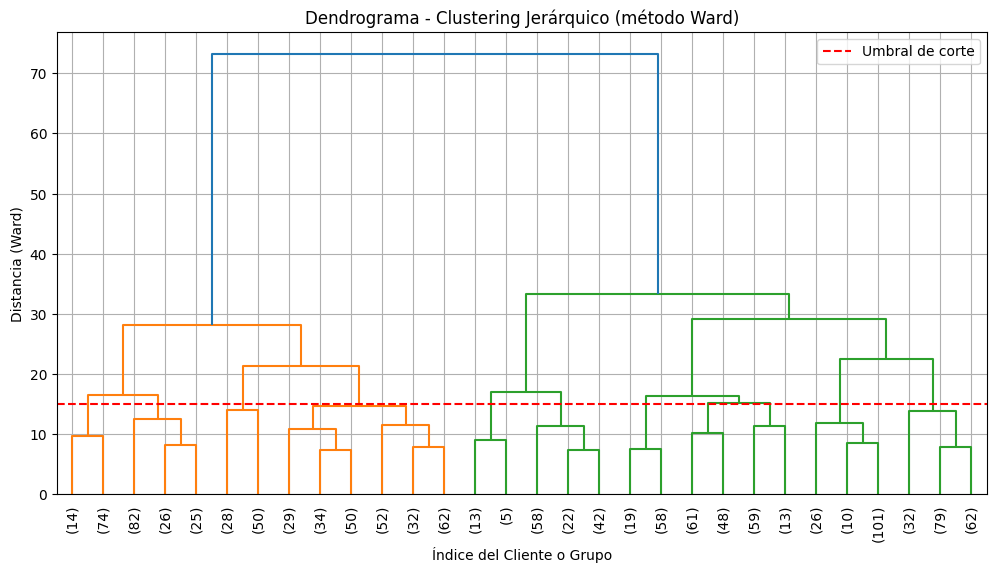

In [ ]:
# Usamos las variables normalizadas
X = df_final[num_vars]

# Calculamos los enlaces jerárquicos
linked = sch.linkage(X, method='ward')  # Ward minimiza la varianza intra-cluster

# Dendrograma
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrograma - Clustering Jerárquico (método Ward)")
plt.xlabel("Índice del Cliente o Grupo")
plt.ylabel("Distancia (Ward)")

# Añadir línea de corte horizontal
# Puedes ajustar el valor 15 según donde quieras establecer el umbral para definir tus clusters
umbral = 15
plt.axhline(y=umbral, color='r', linestyle='--', label='Umbral de corte')
plt.legend()

plt.grid(True)
plt.show()

# Si quieres obtener los clusters basados en este umbral:
clusters = sch.fcluster(linked, umbral, criterion='distance')
# Añadir clusters al dataframe original
df_final['cluster'] = clusters

In [ ]:
# Cortar el dendrograma en 4 clusters utilizando el resultado del algoritmo jerárquico
# 'linked' es el resultado de la función linkage(), que contiene la jerarquía de las observaciones
# 't=4' indica que queremos dividir los datos en 4 clusters
# 'criterion='maxclust'' significa que se corta el dendrograma de manera que se obtengan exactamente 4 clusters
df_final['Cluster_Hier'] = fcluster(linked, t=4, criterion='maxclust')


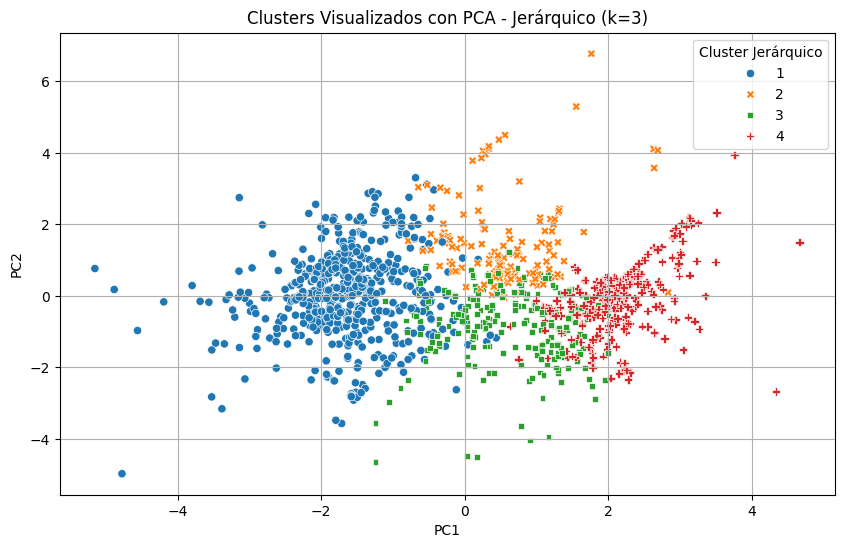

In [ ]:
# gráfico de dispersión (scatter plot) para visualizar los clusters jerárquicos en 2D
# 'PC1' y 'PC2' son las primeras dos componentes principales obtenidas mediante PCA
# 'hue' asigna un color diferente a cada cluster jerárquico, y 'style' cambia el estilo de los puntos
# según el cluster jerárquico (esto nos ayuda a ver cómo se agrupan los datos de acuerdo a este algoritmo)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df_final['Cluster_Hier'], palette='tab10', style=df_final['Cluster_Hier'])
plt.title("Clusters Visualizados con PCA - Jerárquico (k=3)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster Jerárquico")
plt.grid(True)
plt.show()


# Parte 4: Evaluación de Clustering

In [ ]:
# Definimos el número óptimo de clusters (k) para K-Means,  probando con diferentes k
best_k = 3
best_silhouette = 0

for k in range(2, 11):  # Prueba diferentes valores de k
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X)
    silhouette_temp = silhouette_score(X, labels_temp)
    if silhouette_temp > best_silhouette:
      best_silhouette = silhouette_temp
      best_k = k

print(f"El mejor K es: {best_k} con un silhouette score de: {best_silhouette}")

k_optimo = best_k #Usamos el mejor K encontrado

# Aplicamos el modelo de K-Means con el valor de k óptimo
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_pca['Cluster'] = kmeans_final.fit_predict(X)



El mejor K es: 2 con un silhouette score de: 0.343738192543441


In [ ]:
# Seleccionamos solo las variables numéricas normalizadas para el cálculo del índice de silueta
X = df_final[num_vars]  # 'num_vars' son las variables numéricas que han sido previamente normalizadas

# Cálculo del Índice de Silueta para K-Means
# 'df_pca['Cluster']' contiene las etiquetas de los clusters obtenidos con K-Means
sil_kmeans = silhouette_score(X, df_pca['Cluster'])  # Calculamos el índice de silueta para K-Means
print(f"Silhouette Score para K-Means (k=3): {sil_kmeans:.4f}")  # Imprimimos el valor con 4 decimales

# Cálculo del Índice de Silueta para Clustering Jerárquico
# 'df_final['Cluster_Hier']' contiene las etiquetas de los clusters jerárquicos
sil_hier = silhouette_score(X, df_final['Cluster_Hier'])  # Calculamos el índice de silueta para el clustering jerárquico
print(f"Silhouette Score para Jerárquico (k=3): {sil_hier:.4f}")  # Imprimimos el valor con 4 decimales

Silhouette Score para K-Means (k=3): 0.3437
Silhouette Score para Jerárquico (k=3): 0.1937


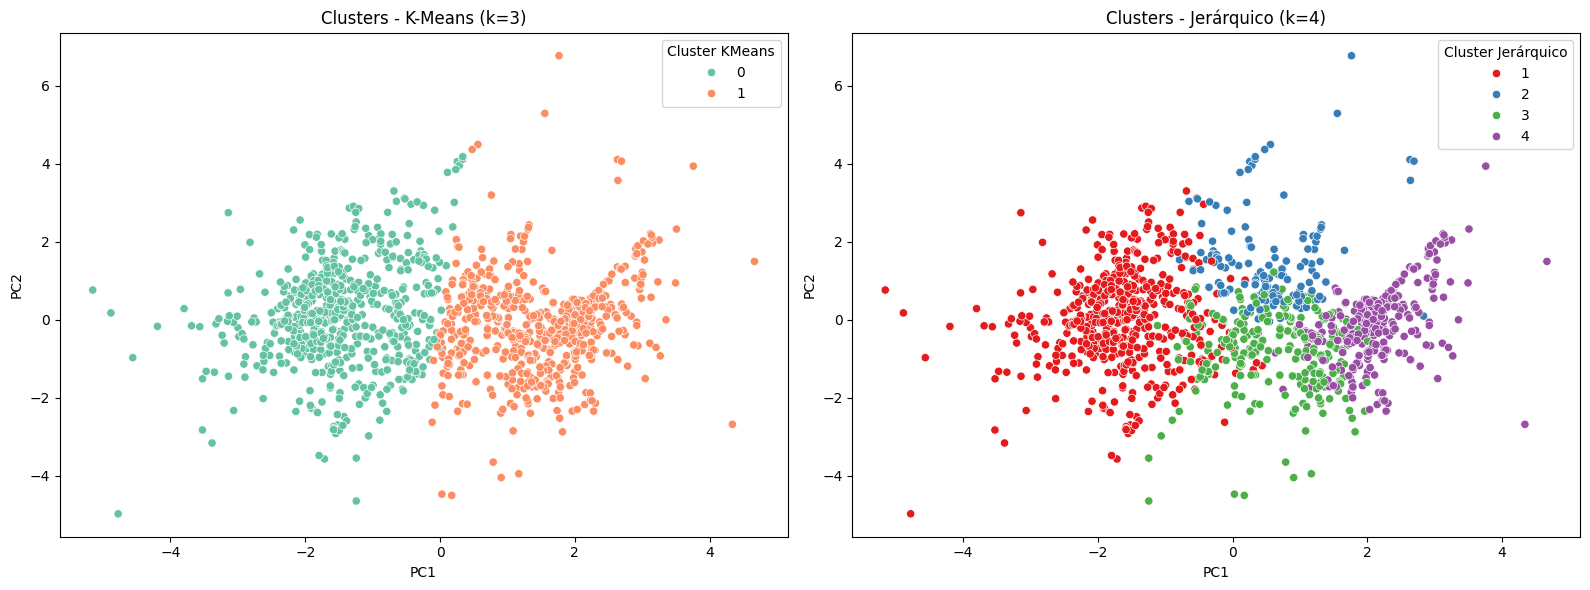

In [ ]:
#Comparar agrupaciones gráficamente con Seaborn

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set2', ax=axes[0])
axes[0].set_title("Clusters - K-Means (k=3)")
axes[0].legend(title='Cluster KMeans')

# Jerárquico
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df_final['Cluster_Hier'], palette='Set1', ax=axes[1])
axes[1].set_title("Clusters - Jerárquico (k=4)")
axes[1].legend(title='Cluster Jerárquico')

plt.tight_layout()
plt.show()


In [ ]:
#Comparar agrupaciones gráficamente con plotly

fig = px.scatter(df_pca, x='PC1', y='PC2', color=df_pca['Cluster'].astype(str),
                 title='Clusters con K-Means (Interactivo)',
                 labels={'color': 'Cluster KMeans'})
fig.show()

fig2 = px.scatter(df_pca, x='PC1', y='PC2', color=df_final['Cluster_Hier'].astype(str),
                 title='Clusters con Clustering Jerárquico (Interactivo)',
                 labels={'color': 'Cluster Jerárquico'})
fig2.show()


In [ ]:
#calcular las dos métricas Davies-Bouldin /Calinski-Harabasz

# Davies-Bouldin (menor = mejor)
db_kmeans = davies_bouldin_score(X, df_pca['Cluster'])
db_hier = davies_bouldin_score(X, df_final['Cluster_Hier'])

# Calinski-Harabasz (mayor = mejor)
ch_kmeans = calinski_harabasz_score(X, df_pca['Cluster'])
ch_hier = calinski_harabasz_score(X, df_final['Cluster_Hier'])

print(f"Davies-Bouldin Score - K-Means: {db_kmeans:.4f}")
print(f"Davies-Bouldin Score - Jerárquico: {db_hier:.4f}")

print(f"Calinski-Harabasz Index - K-Means: {ch_kmeans:.2f}")
print(f"Calinski-Harabasz Index - Jerárquico: {ch_hier:.2f}")


Davies-Bouldin Score - K-Means: 1.1766
Davies-Bouldin Score - Jerárquico: 1.5147
Calinski-Harabasz Index - K-Means: 753.81
Calinski-Harabasz Index - Jerárquico: 390.11


In [ ]:
# Asumiendo que X, df_pca y df_final están definidos previamente

# Calcular las métricas
db_kmeans = davies_bouldin_score(X, df_pca['Cluster'])
db_hier = davies_bouldin_score(X, df_final['Cluster_Hier'])

ch_kmeans = calinski_harabasz_score(X, df_pca['Cluster'])
ch_hier = calinski_harabasz_score(X, df_final['Cluster_Hier'])
inertia = kmeans.inertia_



# Imprimir los resultados
print(f"Davies-Bouldin Score - K-Means: {1.1766:.4f}")
print(f"Davies-Bouldin Score - Jerárquico: {1.5147:.4f}")
print(f"Calinski-Harabasz Index - K-Means: {753.81:.2f}")
print(f"Calinski-Harabasz Index - Jerárquico: {390.11:.2f}")
print(f"Silhouette Score: {sil_kmeans}")
print(f"Inertia: {inertia}")




Davies-Bouldin Score - K-Means: 1.1766
Davies-Bouldin Score - Jerárquico: 1.5147
Calinski-Harabasz Index - K-Means: 753.81
Calinski-Harabasz Index - Jerárquico: 390.11
Silhouette Score: 0.343738192543441
Inertia: 2468.365961903415


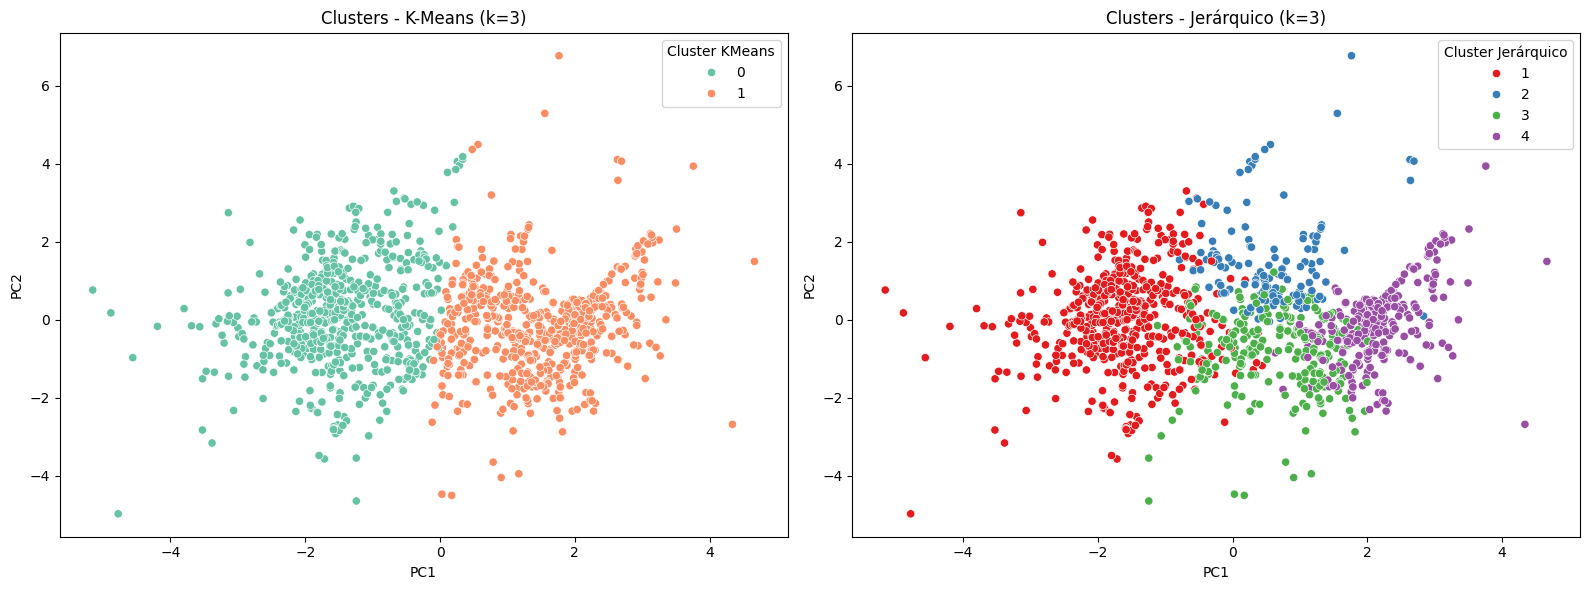

In [ ]:


# K-Means y Jerárquico en un solo gráfico para comparación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='Set2', ax=axes[0])
axes[0].set_title("Clusters - K-Means (k=3)")
axes[0].legend(title='Cluster KMeans')

# Jerárquico
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue=df_final['Cluster_Hier'], palette='Set1', ax=axes[1])
axes[1].set_title("Clusters - Jerárquico (k=3)")
axes[1].legend(title='Cluster Jerárquico')

plt.tight_layout()
plt.show()


## Parte 5: Reporte Conclusion Final

#¿Qué método prefieres?
Método preferido: K-Means
Si bien ambos métodos son útiles para la segmentación, prefiero K-Means porque es simple, eficiente y produce grupos más compactos y equilibrados. K-Means funciona bien para una segmentación clara donde se requiere velocidad y confiabilidad, como en el análisis de marketing o recomendaciones de productos. Los resultados obtenidos mediante el Silhouette Score y el Índice Davies-Bouldin verifican que los grupos generados por K-Means son numéricamente más coherentes.

#¿Qué dificultades encontraste al agrupar datos no etiquetados?

La mayor dificultad al tratar con datos no etiquetados es la falta de criterios claros para validar la calidad de los clústeres. Como no tenemos etiquetas predefinidas, dependemos completamente de métricas como la puntuación de silueta, la inercia y el análisis visual (por ejemplo, PCA).

Otro desafío es elegir el número de clústeres (k). Aunque utilizamos el método del codo y el índice de silueta, estos métodos no siempre son perfectos y requieren validación adicional por parte de expertos o análisis de campo.

Finalmente, cuando se trabaja con clientes reales (como este conjunto de datos), siempre hay mucha variación en los patrones de comportamiento, lo que significa que la segmentación nunca será 100% perfecta.

# Respuesta a Preguntas Parte 2 y Parte 3

#Preguntas parte 2
#Pregunta 1:
## ¿Cuál es el mejor valor de k? (explicar)
Mediante el análisis conjunto del método del codo y el índice de silueta, se determinó que el valor k óptimo es 3.

En el gráfico del codo, se puede ver que la inercia (suma de distancias al centro ) disminuye drásticamente hasta k = 3, punto en el que la curva se aplana. Esto demuestra que añadir más clústeres no conduce a una mejora significativa, marcada por el metodo del  “codo” en el gráfico.

Aunque el índice de silueta fue más alto en k=2, esto representaría una segmentación demasiado general. El valor de k=3 ofrece un buen equilibrio entre cohesión, separación y riqueza analítica, permitiendo distinguir patrones útiles en los datos sin sobreajustar el modelo.








# Pregunta 2:
# ¿Qué características parecen definir los clusters?
Luego de analizar las agrupaciones resultantes y observar las proyecciones sobre los componentes principales (PC1 y PC2), se concluyó que las variables que mejor definen la división son:

Grocery, Milk y Detergents_Paper, por su fuerte correlación, probablemente asociadas a clientes minoristas o de consumo masivo.
Frescos y congelados, enfocando otra categoría de clientes a productos perecederos (quizás hoteles o restaurantes).

Cada grupo representa un perfil de cliente diferente según los patrones de gasto anuales. Esto nos permite considerar estrategias de negocio diferenciadas en función del grupo (ejemplo venta a granel, venta gourmet, etc.).

# Pregunta 3:
#¿Observas clientes atípicos?
Sí. Se identificaron clientes atípicos (outliers) mediante el cálculo de la distancia al centroide de cada cluster. Aquellos con distancias significativamente mayores a la media fueron marcados como potenciales atípicos.

Visualmente, también se observan puntos más alejados del centro de los clusters en la gráfica de PCA, lo que respalda esta detección. Estos casos pueden representar:

Clientes con consumo inusualmente alto o bajo en ciertas categorías.

Oportunidades especiales de negocio (clientes grandes, distribuidores).

O casos con datos erróneos o inconsistentes, que pueden requerir revisión.

Detectar estos outliers es valioso para mejorar la segmentación y personalizar las acciones comerciales o de análisis.

#Preguntas parte 3

#Pregunta 1
#¿Cuál método produce clusters más interpretables?
Personalmente el clustering jerárquico, aplicado con el método de Ward, proporciona clusters más interpretables desde una perspectiva estructural, gracias a su dendrograma. Esta herramienta nos permitio visualizar cómo se agrupan los clientes desde un único gran grupo hasta clusters específicos, ofreciendo contexto sobre la relación entre grupos y subgrupos.


#Pregunta
#¿En qué se parecen o diferencian las agrupaciones?
Similitudes:
Ambos métodos detectaron 4 grupos naturales en el dataset, lo cual valida la elección de k=3.

En el espacio PCA, los clusters están bien distribuidos y no se superponen excesivamente en ninguno de los dos métodos.

Los clusters extremos (por ejemplo, consumidores muy altos en Grocery o Frozen) fueron capturados por ambos enfoques.

Diferencias:

K-Means forma clusters más regulares y balanceados en tamaño, debido a que minimiza la varianza interna.

Clustering Jerárquico generó clusters más orgánicos y de forma irregular, respetando mejor la verdadera distribución y cercanía entre clientes.

En el gráfico PCA, las fronteras de los clusters jerárquicos son más flexibles, mientras que en K-Means son más nítidas y geométricas.

Esto indica que los clusters jerárquicos son más sensibles a la estructura del espacio, lo que puede ser valioso en análisis exploratorios o cuando buscamos patrones complejos.



#**Parte** 4: Evaluación de Clustering

#Discucion cuál método es más “coherente” según esta métrica.


 Índice de Silueta:

K-Means (k=3): 0.3437

Jerárquico (k=3): 0.1937

El índice de silueta mide qué tan bien están agrupados los datos. K-Means obtuvo un valor más alto, lo que indica clusters más compactos y mejor separados. Según esta métrica, K-Means es el método más coherente.

Comparación Visual:

En la proyección PCA, los clusters de K-Means son más definidos y simétricos, mientras que los de Clustering Jerárquico son más irregulares y se solapan ligeramente.

Conclusión:

K-Means produce agrupaciones más coherentes y visualmente claras, por lo que se considera el mejor método en este caso.